# PIRATE peak-finder final benchmark

Final comparison of **Bowtie banks** and **Full-band bowtie**.

In [1]:
from pathlib import Path
import os

_results_override = os.environ.get('PEAKFINDER_RESULTS_DIR')
if _results_override:
    RESULTS_DIR = Path(_results_override).expanduser()
elif (Path.cwd() / 'peakfinder_tests').is_dir():
    RESULTS_DIR = Path.cwd() / 'peakfinder_tests' / 'results_final'
elif Path.cwd().name == 'peakfinder_tests':
    RESULTS_DIR = Path.cwd() / 'results_final'
else:
    raise RuntimeError('Run the notebook from the PIRATE repository root or peakfinder_tests directory')
SCHEMA_VERSION = 3
METHODS = ('bowtie_banks', 'full_band_bowtie')
METHOD_LABELS = {
    'bowtie_banks': 'Bowtie banks',
    'full_band_bowtie': 'Full-band bowtie',
}
METHOD_COLORS = {
    'bowtie_banks': '#0072B2',
    'full_band_bowtie': '#D55E00',
}
N_DM = (128, 256, 512, 1024, 2048, 4096)
N_T = (16, 32, 64, 128, 256, 512, 1024, 2048, 4096)
SEPARATIONS_MS = tuple(range(5, 21))
WARMUP_CALLS = 5
TIMED_CALLS = 50

In [2]:
import csv
from collections import defaultdict

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
import yaml


def _read_csv(path):
    if not path.is_file():
        raise FileNotFoundError(path)
    with path.open(newline='') as stream:
        reader = csv.DictReader(stream)
        columns = tuple(reader.fieldnames or ())
        if len(columns) != len(set(columns)):
            raise ValueError(f'{path}: duplicate CSV columns')
        rows = list(reader)
    if not rows:
        raise ValueError(f'{path}: result file is empty')
    return columns, rows


def _require_columns(columns, required, name):
    missing = sorted(set(required) - set(columns))
    if missing:
        raise ValueError(f'{name}: missing required columns {missing}')


def _integer(value, context):
    try:
        result = int(value)
    except (TypeError, ValueError) as exc:
        raise ValueError(f'{context}: expected an integer, got {value!r}') from exc
    return result


def _finite(value, context):
    try:
        result = float(value)
    except (TypeError, ValueError) as exc:
        raise ValueError(f'{context}: expected a number, got {value!r}') from exc
    if not np.isfinite(result):
        raise ValueError(f'{context}: expected a finite number, got {value!r}')
    return result


def _strict_bool(value, context):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    normalized = str(value).strip().lower()
    if normalized in {'true', '1'}:
        return True
    if normalized in {'false', '0'}:
        return False
    raise ValueError(f'{context}: expected a boolean, got {value!r}')


def _validate_common(columns, rows, required, name):
    _require_columns(columns, required, name)
    versions = {_integer(row['schema_version'], f'{name}:schema_version') for row in rows}
    if versions != {SCHEMA_VERSION}:
        raise ValueError(f'{name}: expected only schema v{SCHEMA_VERSION}, got {versions}')
    methods = {row['method'] for row in rows}
    if methods != set(METHODS):
        raise ValueError(f'{name}: expected exactly {METHODS}, got {sorted(methods)}')


def _validate_section(metadata, name):
    section = metadata.get(name)
    if not isinstance(section, dict):
        raise ValueError(f'metadata.yaml: missing {name!r} section')
    parameters = section.get('scientific_parameters')
    if not isinstance(parameters, dict):
        raise ValueError(f'metadata.yaml:{name}: missing scientific_parameters')
    for key in ('intended_logical_units', 'completed_logical_units', 'complete'):
        if key not in section:
            raise ValueError(f'metadata.yaml:{name}: missing {key!r}')
    intended = _integer(section['intended_logical_units'], f'metadata.yaml:{name}:intended')
    completed = _integer(section['completed_logical_units'], f'metadata.yaml:{name}:completed')
    if intended < 1 or completed != intended or not _strict_bool(section['complete'], f'metadata.yaml:{name}:complete'):
        raise ValueError(f'metadata.yaml:{name}: benchmark is incomplete')
    return section, parameters, intended


def _require_number(parameters, aliases, expected, context):
    present = [key for key in aliases if key in parameters]
    if not present:
        raise ValueError(f'{context}: missing one of {aliases}')
    values = [_finite(parameters[key], f'{context}:{key}') for key in present]
    if any(not np.isclose(value, expected, rtol=0.0, atol=1.0e-12) for value in values):
        raise ValueError(f'{context}: expected {expected}, got {dict(zip(present, values))}')
    return values[0]


def _require_integer_parameter(parameters, aliases, context):
    present = [key for key in aliases if key in parameters]
    if not present:
        raise ValueError(f'{context}: missing one of {aliases}')
    values = [_integer(parameters[key], f'{context}:{key}') for key in present]
    if len(set(values)) != 1:
        raise ValueError(f'{context}: inconsistent values {dict(zip(present, values))}')
    return values[0]


def _validate_method_pair(rows, shared_fields, context):
    if len(rows) != len(METHODS) or {row['method'] for row in rows} != set(METHODS):
        raise ValueError(f'{context}: expected one row per method')
    for field in shared_fields:
        values = {row[field] for row in rows}
        if len(values) != 1:
            raise ValueError(f'{context}: methods do not share {field}')


def _validate_channel_coverage(row, context):
    compact = str(row['active_channel_indices']).strip()
    parts = compact.split(':')
    if len(parts) != 2 or not all(part.isdigit() for part in parts):
        raise ValueError(f'{context}: active_channel_indices must be compact start:stop')
    first, stop = map(int, parts)
    count = _integer(row['active_channel_count'], f'{context}:active_channel_count')
    if first < 0 or stop <= first or count != stop - first or compact != f'{first}:{stop}':
        raise ValueError(f'{context}: inconsistent compact active-channel coverage')
    requested_lo = _finite(row['requested_freq_lo_MHz'], f'{context}:requested_freq_lo_MHz')
    requested_hi = _finite(row['requested_freq_hi_MHz'], f'{context}:requested_freq_hi_MHz')
    effective_lo = _finite(row['effective_active_freq_lo_MHz'], f'{context}:effective_active_freq_lo_MHz')
    effective_hi = _finite(row['effective_active_freq_hi_MHz'], f'{context}:effective_active_freq_hi_MHz')
    tolerance = 1.0e-9
    if not (300.0 - tolerance <= effective_lo < effective_hi <= 1500.0 + tolerance):
        raise ValueError(f'{context}: effective active-channel bounds are invalid')
    if effective_lo > requested_lo + tolerance or effective_hi < requested_hi - tolerance:
        raise ValueError(f'{context}: effective channels do not cover the requested interval')


paths = {
    name: RESULTS_DIR / name
    for name in ('runtime.csv', 'recall.csv', 'separability.csv', 'metadata.yaml')
}
runtime_columns, runtime_rows = _read_csv(paths['runtime.csv'])
recall_columns, recall_rows = _read_csv(paths['recall.csv'])
separability_columns, separability_rows = _read_csv(paths['separability.csv'])
if not paths['metadata.yaml'].is_file():
    raise FileNotFoundError(paths['metadata.yaml'])
with paths['metadata.yaml'].open() as stream:
    metadata = yaml.safe_load(stream) or {}

suite = metadata.get('suite')
if not isinstance(suite, dict):
    raise ValueError('metadata.yaml: missing suite section')
if _integer(suite.get('schema_version'), 'metadata.yaml:suite:schema_version') != SCHEMA_VERSION:
    raise ValueError(f'metadata.yaml: expected schema v{SCHEMA_VERSION}')
if tuple(suite.get('methods', ())) != METHODS:
    raise ValueError(f'metadata.yaml: expected methods {METHODS}')

runtime_meta, runtime_parameters, runtime_intended = _validate_section(metadata, 'runtime')
recall_meta, recall_parameters, recall_intended = _validate_section(metadata, 'recall')
separability_meta, separability_parameters, separability_intended = _validate_section(metadata, 'separability')
for section_name, parameters in (
    ('runtime', runtime_parameters),
    ('recall', recall_parameters),
    ('separability', separability_parameters),
):
    _require_number(parameters, ('threshold',), 10.0, f'metadata.yaml:{section_name}')
    _require_number(parameters, ('dm_reach',), 8.0, f'metadata.yaml:{section_name}')
    _require_number(parameters, ('waist_bins',), 1.0, f'metadata.yaml:{section_name}')

_require_number(runtime_parameters, ('warmup', 'warmup_calls'), WARMUP_CALLS, 'metadata.yaml:runtime')
_require_number(runtime_parameters, ('iterations', 'timed_calls'), TIMED_CALLS, 'metadata.yaml:runtime')
runtime_geometry_tree = _require_integer_parameter(runtime_parameters, ('geometry_tree',), 'metadata.yaml:runtime')
runtime_shape_seeds = None
if 'shape_seeds' in runtime_meta:
    entries = runtime_meta['shape_seeds']
    if not isinstance(entries, list):
        raise ValueError('metadata.yaml:runtime: shape_seeds must be a list')
    runtime_shape_seeds = {}
    for index, entry in enumerate(entries):
        if not isinstance(entry, dict) or not {'ndm', 'nt', 'map_seed'} <= set(entry):
            raise ValueError(f'metadata.yaml:runtime:shape_seeds:{index}: invalid entry')
        key = (
            _integer(entry['ndm'], f'metadata.yaml:runtime:shape_seeds:{index}:ndm'),
            _integer(entry['nt'], f'metadata.yaml:runtime:shape_seeds:{index}:nt'),
        )
        if key in runtime_shape_seeds:
            raise ValueError(f'metadata.yaml:runtime: duplicate shape seed for {key}')
        runtime_shape_seeds[key] = _integer(
            entry['map_seed'], f'metadata.yaml:runtime:shape_seeds:{index}:map_seed')
    if set(runtime_shape_seeds) != {(ndm, nt) for ndm in N_DM for nt in N_T}:
        raise ValueError('metadata.yaml:runtime: shape_seeds does not cover the runtime grid')

runtime_required = (
    'schema_version', 'method', 'ndm', 'nt', 'npixels', 'geometry_tree',
    'map_seed', 'warmup_calls', 'timed_calls', 'iteration', 'gpu_time_ms',
    'mean_gpu_time_ms',
    'median_gpu_time_ms', 'std_gpu_time_ms',
)
_validate_common(runtime_columns, runtime_rows, runtime_required, 'runtime.csv')
runtime_groups = defaultdict(list)
for lineno, row in enumerate(runtime_rows, start=2):
    ndm = _integer(row['ndm'], f'runtime.csv:{lineno}:ndm')
    nt = _integer(row['nt'], f'runtime.csv:{lineno}:nt')
    if ndm not in N_DM or nt not in N_T:
        raise ValueError(f'runtime.csv:{lineno}: unexpected shape ({ndm}, {nt})')
    if _integer(row['npixels'], f'runtime.csv:{lineno}:npixels') != ndm * nt:
        raise ValueError(f'runtime.csv:{lineno}: npixels does not equal ndm * nt')
    iteration = _integer(row['iteration'], f'runtime.csv:{lineno}:iteration')
    gpu_time = _finite(row['gpu_time_ms'], f'runtime.csv:{lineno}:gpu_time_ms')
    if gpu_time < 0:
        raise ValueError(f'runtime.csv:{lineno}: negative GPU time')
    _integer(row['map_seed'], f'runtime.csv:{lineno}:map_seed')
    geometry_tree = _integer(row['geometry_tree'], f'runtime.csv:{lineno}:geometry_tree')
    if geometry_tree != runtime_geometry_tree:
        raise ValueError(f'runtime.csv:{lineno}: geometry_tree does not match metadata')
    if 'warmup' in runtime_columns and _integer(row['warmup'], f'runtime.csv:{lineno}:warmup') != WARMUP_CALLS:
        raise ValueError(f'runtime.csv:{lineno}: warmup mismatch')
    if 'warmup_calls' in runtime_columns and _integer(row['warmup_calls'], f'runtime.csv:{lineno}:warmup_calls') != WARMUP_CALLS:
        raise ValueError(f'runtime.csv:{lineno}: warmup_calls mismatch')
    if _integer(row['timed_calls'], f'runtime.csv:{lineno}:timed_calls') != TIMED_CALLS:
        raise ValueError(f'runtime.csv:{lineno}: timed_calls mismatch')
    if 'iterations' in runtime_columns and _integer(row['iterations'], f'runtime.csv:{lineno}:iterations') != TIMED_CALLS:
        raise ValueError(f'runtime.csv:{lineno}: iterations mismatch')
    runtime_groups[(row['method'], ndm, nt)].append((iteration, gpu_time, row))

expected_runtime_groups = {
    (method, ndm, nt) for method in METHODS for ndm in N_DM for nt in N_T
}
if set(runtime_groups) != expected_runtime_groups:
    raise ValueError('runtime.csv: incomplete or duplicate method/shape grid')
if runtime_intended != len(N_DM) * len(N_T):
    raise ValueError('metadata.yaml:runtime: incorrect logical-unit count')

runtime_means = {method: {} for method in METHODS}
runtime_stds = {method: {} for method in METHODS}
for ndm in N_DM:
    for nt in N_T:
        input_signatures = {}
        for method in METHODS:
            entries = runtime_groups[(method, ndm, nt)]
            iterations = [entry[0] for entry in entries]
            if len(entries) != TIMED_CALLS or sorted(iterations) != list(range(TIMED_CALLS)):
                raise ValueError(f'runtime.csv:{method}:({ndm},{nt}): expected iterations 0..{TIMED_CALLS - 1}')
            values = np.asarray([entry[1] for entry in entries], dtype=float)
            mean = float(np.mean(values))
            median = float(np.median(values))
            std = float(np.std(values, ddof=0))
            for _, _, row in entries:
                recorded = {
                    'mean_gpu_time_ms': mean,
                    'median_gpu_time_ms': median,
                    'std_gpu_time_ms': std,
                }
                for field, expected in recorded.items():
                    observed = _finite(row[field], f'runtime.csv:{method}:({ndm},{nt}):{field}')
                    if not np.isclose(observed, expected, rtol=1.0e-10, atol=1.0e-12):
                        raise ValueError(f'runtime.csv:{method}:({ndm},{nt}): inconsistent {field}')
            seeds = {_integer(entry[2]['map_seed'], 'runtime.csv:map_seed') for entry in entries}
            trees = {_integer(entry[2]['geometry_tree'], 'runtime.csv:geometry_tree') for entry in entries}
            if len(seeds) != 1 or len(trees) != 1:
                raise ValueError(f'runtime.csv:{method}:({ndm},{nt}): input identity varies across timings')
            input_signatures[method] = (next(iter(seeds)), next(iter(trees)))
            runtime_means[method][(ndm, nt)] = mean
            runtime_stds[method][(ndm, nt)] = std
        if len(set(input_signatures.values())) != 1:
            raise ValueError(f'runtime.csv: methods did not receive the same map at ({ndm},{nt})')
        if runtime_shape_seeds is not None:
            observed_seed = next(iter(input_signatures.values()))[0]
            if observed_seed != runtime_shape_seeds[(ndm, nt)]:
                raise ValueError(f'runtime.csv: map_seed disagrees with metadata at ({ndm},{nt})')

timing_mean_matrices = {
    method: np.asarray([[runtime_means[method][(ndm, nt)] for nt in N_T] for ndm in N_DM])
    for method in METHODS
}
timing_std_matrices = {
    method: np.asarray([[runtime_stds[method][(ndm, nt)] for nt in N_T] for ndm in N_DM])
    for method in METHODS
}
all_timing_means = np.concatenate([timing_mean_matrices[method].ravel() for method in METHODS])
timing_vmin = float(np.min(all_timing_means))
timing_vmax = float(np.max(all_timing_means))
if np.isclose(timing_vmin, timing_vmax):
    timing_vmax = timing_vmin + max(abs(timing_vmin), 1.0) * 1.0e-12
timing_normalization = Normalize(vmin=timing_vmin, vmax=timing_vmax)


def _plot_runtime_heatmap(method):
    means = timing_mean_matrices[method]
    stds = timing_std_matrices[method]
    fig, ax = plt.subplots(figsize=(11.5, 5.8), constrained_layout=True)
    image = ax.imshow(means, origin='upper', aspect='auto', cmap='Blues', norm=timing_normalization)
    ax.set_xticks(np.arange(len(N_T)), [str(value) for value in N_T])
    ax.set_yticks(np.arange(len(N_DM)), [str(value) for value in N_DM])
    ax.set_xlabel('N_t')
    ax.set_ylabel('N_DM')
    ax.set_title(f'{METHOD_LABELS[method]} mean GPU time')
    for iy in range(len(N_DM)):
        for ix in range(len(N_T)):
            color = 'white' if timing_normalization(means[iy, ix]) > 0.55 else 'black'
            ax.text(ix, iy, f'{means[iy, ix]:.3f} ±\n{stds[iy, ix]:.3f}',
                    ha='center', va='center', fontsize=7, color= "coral")
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label('Mean GPU time (ms)')
    plt.show()


recall_required = (
    'schema_version', 'trial', 'method', 'map_id', 'parameter_seed',
    'trial_seed', 'injected_dm', 'injected_snr', 'injected_width_ms',
    'requested_freq_lo_MHz', 'requested_freq_hi_MHz', 'injected_toa_s',
    'active_channel_indices', 'active_channel_count',
    'effective_active_freq_lo_MHz', 'effective_active_freq_hi_MHz',
    'detected', 'candidate_set_containment',
)
_validate_common(recall_columns, recall_rows, recall_required, 'recall.csv')
recall_trials = _integer(recall_meta.get('intended_trials', recall_intended), 'metadata.yaml:recall:intended_trials')
if recall_trials < 1 or recall_intended != recall_trials:
    raise ValueError('metadata.yaml:recall: inconsistent intended trial count')
recall_by_trial = defaultdict(list)
for lineno, row in enumerate(recall_rows, start=2):
    trial = _integer(row['trial'], f'recall.csv:{lineno}:trial')
    recall_by_trial[trial].append(row)
if set(recall_by_trial) != set(range(recall_trials)):
    raise ValueError('recall.csv: trials must be contiguous and complete')

recall_shared_fields = (
    'trial', 'map_id', 'parameter_seed', 'trial_seed', 'injected_dm',
    'injected_snr', 'injected_width_ms', 'requested_freq_lo_MHz',
    'requested_freq_hi_MHz', 'active_channel_indices',
    'active_channel_count', 'effective_active_freq_lo_MHz',
    'effective_active_freq_hi_MHz', 'injected_toa_s',
)
recall_parameter_seeds = set()
recall_trial_seeds = set()
recall_outcomes = {method: [] for method in METHODS}
for trial, rows in sorted(recall_by_trial.items()):
    context = f'recall.csv:trial={trial}'
    _validate_method_pair(rows, recall_shared_fields, context)
    row0 = rows[0]
    if not str(row0['map_id']).strip():
        raise ValueError(f'{context}: empty map_id')
    recall_parameter_seeds.add(_integer(row0['parameter_seed'], f'{context}:parameter_seed'))
    recall_trial_seeds.add(_integer(row0['trial_seed'], f'{context}:trial_seed'))
    dm = _finite(row0['injected_dm'], f'{context}:injected_dm')
    snr = _finite(row0['injected_snr'], f'{context}:injected_snr')
    width = _finite(row0['injected_width_ms'], f'{context}:injected_width_ms')
    freq_lo = _finite(row0['requested_freq_lo_MHz'], f'{context}:requested_freq_lo_MHz')
    freq_hi = _finite(row0['requested_freq_hi_MHz'], f'{context}:requested_freq_hi_MHz')
    _finite(row0['injected_toa_s'], f'{context}:injected_toa_s')
    #if not (20.0 <= dm <= 150.0 and 8.0 <= snr <= 20.0 and 0.5 <= width <= 64.0):
    #    raise ValueError(f'{context}: injected parameters lie outside the configured ranges')
    if not (300.0 <= freq_lo < freq_hi <= 1500.0 and freq_hi - freq_lo >= 30.0 - 1.0e-9):
        raise ValueError(f'{context}: requested spectral interval is invalid')
    _validate_channel_coverage(row0, context)
    for row in rows:
        if not _strict_bool(row['candidate_set_containment'], f'{context}:containment'):
            raise ValueError(f'{context}: candidate-set containment failed')
        recall_outcomes[row['method']].append(_strict_bool(row['detected'], f'{context}:detected'))
if len(recall_parameter_seeds) != 1 or len(recall_trial_seeds) != recall_trials:
    raise ValueError('recall.csv: parameter/trial seed bookkeeping is inconsistent')
recall_metadata_seed = _require_integer_parameter(recall_parameters, ('parameter_seed',), 'metadata.yaml:recall')
if recall_parameter_seeds != {recall_metadata_seed}:
    raise ValueError('recall.csv: parameter_seed does not match metadata')
if 'candidate_set_containment_passed' in recall_meta and not _strict_bool(recall_meta['candidate_set_containment_passed'], 'metadata.yaml:recall:containment'):
    raise ValueError('metadata.yaml:recall: candidate-set containment failed')

separability_required = (
    'schema_version', 'separation_ms', 'trial', 'method', 'map_id',
    'parameter_seed', 'trial_seed', 'injected_dm', 'injected_snr',
    'injected_width_ms', 'requested_freq_lo_MHz',
    'requested_freq_hi_MHz', 'injected_toa_1_s', 'injected_toa_2_s',
    'active_channel_indices', 'active_channel_count',
    'effective_active_freq_lo_MHz', 'effective_active_freq_hi_MHz',
    'both_separately_detected', 'candidate_set_containment',
)
_validate_common(separability_columns, separability_rows, separability_required, 'separability.csv')
separability_trials = _integer(separability_meta.get('intended_trials'), 'metadata.yaml:separability:intended_trials')
if separability_trials < 1 or separability_intended != len(SEPARATIONS_MS) * separability_trials:
    raise ValueError('metadata.yaml:separability: inconsistent intended trial count')
_require_number(separability_parameters, ('injected_width_ms', 'width_ms'), 1.0, 'metadata.yaml:separability')
_require_number(separability_parameters, ('injected_snr', 'snr'), 20.0, 'metadata.yaml:separability')

separability_by_unit = defaultdict(list)
for lineno, row in enumerate(separability_rows, start=2):
    separation = _finite(row['separation_ms'], f'separability.csv:{lineno}:separation_ms')
    matches = [value for value in SEPARATIONS_MS if np.isclose(separation, value, rtol=0.0, atol=1.0e-9)]
    if len(matches) != 1:
        raise ValueError(f'separability.csv:{lineno}: unexpected separation {separation}')
    trial = _integer(row['trial'], f'separability.csv:{lineno}:trial')
    separability_by_unit[(matches[0], trial)].append(row)
expected_separability_units = {
    (separation, trial)
    for separation in SEPARATIONS_MS for trial in range(separability_trials)
}
if set(separability_by_unit) != expected_separability_units:
    raise ValueError('separability.csv: separation/trial grid is incomplete')

separability_shared_fields = (
    'separation_ms', 'trial', 'map_id', 'parameter_seed', 'trial_seed',
    'injected_dm', 'injected_snr', 'injected_width_ms',
    'requested_freq_lo_MHz', 'requested_freq_hi_MHz',
    'active_channel_indices', 'active_channel_count',
    'effective_active_freq_lo_MHz', 'effective_active_freq_hi_MHz',
    'injected_toa_1_s', 'injected_toa_2_s',
)
separability_parameter_seeds = set()
separability_trial_seeds = set()
separability_outcomes = {
    (method, separation): []
    for method in METHODS for separation in SEPARATIONS_MS
}
for (separation, trial), rows in sorted(separability_by_unit.items()):
    context = f'separability.csv:separation={separation}:trial={trial}'
    _validate_method_pair(rows, separability_shared_fields, context)
    row0 = rows[0]
    if not str(row0['map_id']).strip():
        raise ValueError(f'{context}: empty map_id')
    separability_parameter_seeds.add(_integer(row0['parameter_seed'], f'{context}:parameter_seed'))
    separability_trial_seeds.add(_integer(row0['trial_seed'], f'{context}:trial_seed'))
    dm = _finite(row0['injected_dm'], f'{context}:injected_dm')
    snr = _finite(row0['injected_snr'], f'{context}:injected_snr')
    width = _finite(row0['injected_width_ms'], f'{context}:injected_width_ms')
    freq_lo = _finite(row0['requested_freq_lo_MHz'], f'{context}:requested_freq_lo_MHz')
    freq_hi = _finite(row0['requested_freq_hi_MHz'], f'{context}:requested_freq_hi_MHz')
    toa1 = _finite(row0['injected_toa_1_s'], f'{context}:injected_toa_1_s')
    toa2 = _finite(row0['injected_toa_2_s'], f'{context}:injected_toa_2_s')
    if not 20.0 <= dm <= 150.0:
        raise ValueError(f'{context}: injected DM lies outside the configured range')
    if not np.isclose(snr, 20.0, rtol=0.0, atol=1.0e-12) or not np.isclose(width, 1.0, rtol=0.0, atol=1.0e-12):
        raise ValueError(f'{context}: injected S/N or width differs from the fixed configuration')
    if not (300.0 <= freq_lo < freq_hi <= 1500.0 and freq_hi - freq_lo >= 30.0 - 1.0e-9):
        raise ValueError(f'{context}: requested spectral interval is invalid')
    _validate_channel_coverage(row0, context)
    if not np.isclose(1000.0 * (toa2 - toa1), separation, rtol=0.0, atol=1.0e-6):
        raise ValueError(f'{context}: injected TOA difference does not match separation_ms')
    for row in rows:
        if not _strict_bool(row['candidate_set_containment'], f'{context}:containment'):
            raise ValueError(f'{context}: candidate-set containment failed')
        outcome = _strict_bool(row['both_separately_detected'], f'{context}:both_separately_detected')
        separability_outcomes[(row['method'], separation)].append(outcome)
if len(separability_parameter_seeds) != 1 or len(separability_trial_seeds) != separability_intended:
    raise ValueError('separability.csv: parameter/trial seed bookkeeping is inconsistent')
separability_metadata_seed = _require_integer_parameter(separability_parameters, ('parameter_seed',), 'metadata.yaml:separability')
if separability_parameter_seeds != {separability_metadata_seed}:
    raise ValueError('separability.csv: parameter_seed does not match metadata')
if 'candidate_set_containment_passed' in separability_meta and not _strict_bool(separability_meta['candidate_set_containment_passed'], 'metadata.yaml:separability:containment'):
    raise ValueError('metadata.yaml:separability: candidate-set containment failed')

## Simulation 1 — computing time

Colour is mean GPU time in milliseconds; annotations show mean ± population standard deviation.

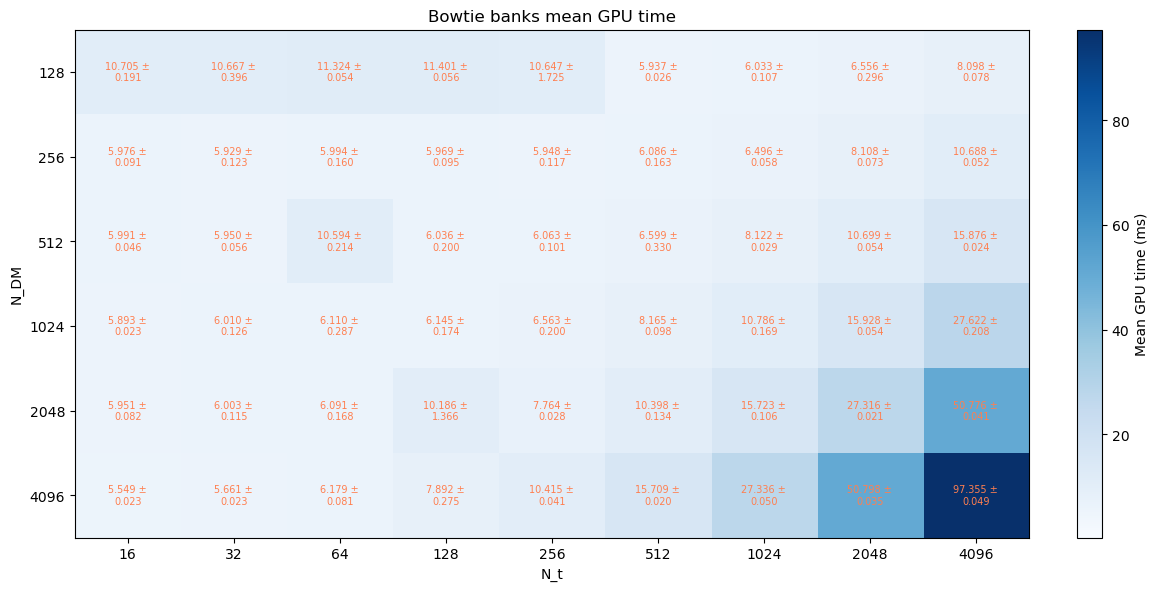

In [3]:
_plot_runtime_heatmap('bowtie_banks')

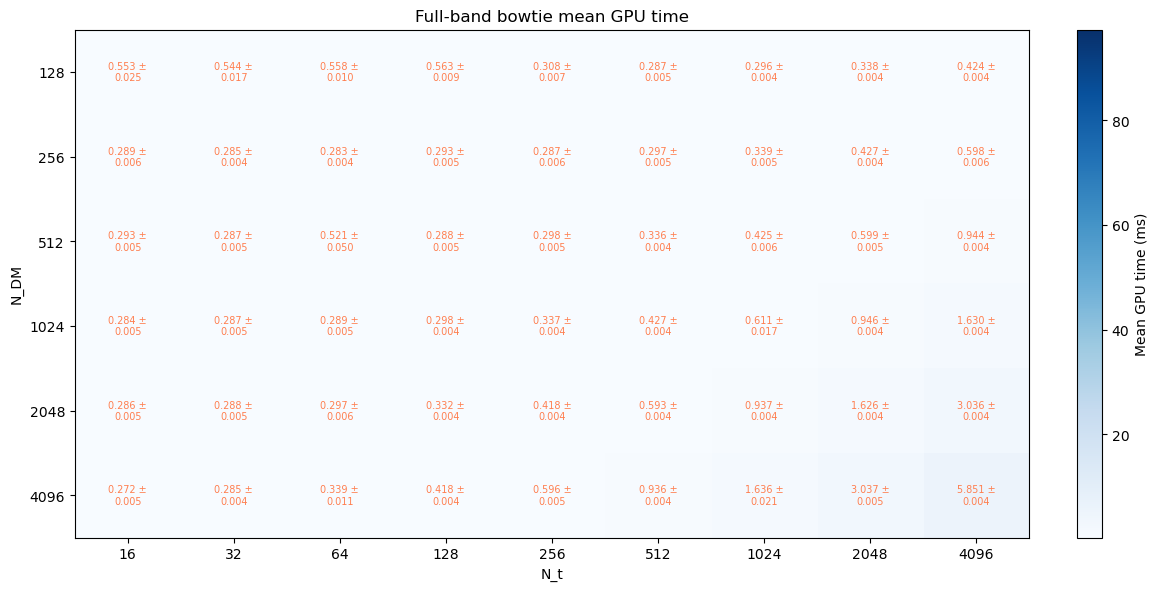

In [4]:
_plot_runtime_heatmap('full_band_bowtie')

## Simulation 2 — single-burst recall

Recall is the fraction of injected bursts associated with at least one returned candidate.

In [5]:
for method in METHODS:
    detected = int(sum(recall_outcomes[method]))
    total = len(recall_outcomes[method])
    percentage = 100.0 * detected / total
    print(f'{METHOD_LABELS[method]} recall: {detected} / {total} = {percentage:.2f}%')

Bowtie banks recall: 189 / 200 = 94.50%
Full-band bowtie recall: 189 / 200 = 94.50%


## Simulation 3 — temporal separability

The plotted percentage is the fraction of trials in which two distinct candidates were associated one-to-one with the two 1 ms bursts.

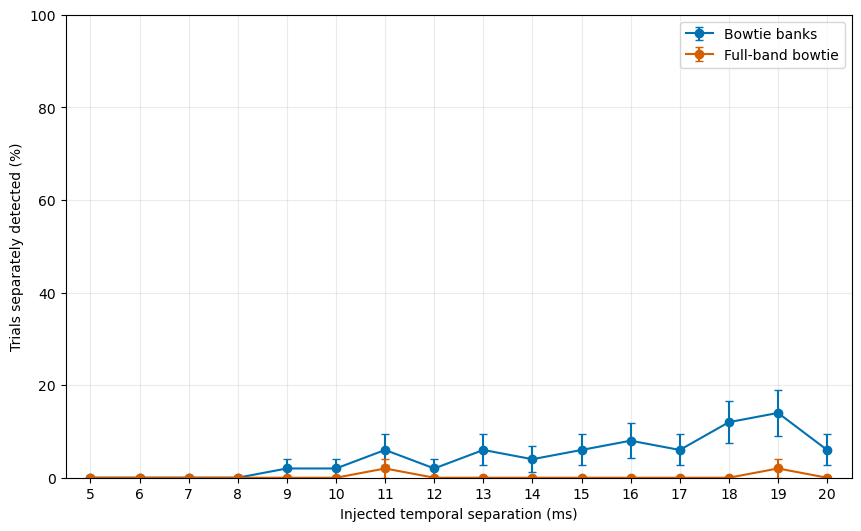

In [6]:
x = np.asarray(SEPARATIONS_MS, dtype=float)
fig, ax = plt.subplots(figsize=(8.5, 5.2), constrained_layout=True)
for method in METHODS:
    fractions = []
    errors = []
    for separation in SEPARATIONS_MS:
        outcomes = np.asarray(separability_outcomes[(method, separation)], dtype=float)
        fraction = float(np.mean(outcomes))
        fractions.append(100.0 * fraction)
        errors.append(100.0 * np.sqrt(fraction * (1.0 - fraction) / len(outcomes)))
    ax.errorbar(x, fractions, yerr=errors, marker='o', linewidth=1.5,
                capsize=3, color=METHOD_COLORS[method], label=METHOD_LABELS[method])
ax.set_xlabel('Injected temporal separation (ms)')
ax.set_ylabel('Trials separately detected (%)')
ax.set_xticks(x)
ax.set_xlim(SEPARATIONS_MS[0] - 0.5, SEPARATIONS_MS[-1] + 0.5)
ax.set_ylim(0.0, 100.0)
ax.grid(alpha=0.25)
ax.legend()
plt.show()